# **Climate Forecasting using Machine Learning: 05 Model Hypertuning**

---

### **Notebook Summary**

This notebook tunes bounded hyperparameter options for the retained model set after feature, recency, global-selection, AR lag, and ENSO lag choices have been fixed. The goal is to choose one validation-selected setting for each retained model before the residual climatology notebooks reuse those settings.

### **Model tuning settings**
- H = 1
- AR + ENSO features
- SST off
- selected AR lag structure fixed
- selected ENSO lag set fixed
- 48-month recency weighting fixed
- global model selection fixed
- retained models: Ridge, Huber, XGBoost, LSTM, PatchTST, iTransformer, NHiTS
- random seed = 42

### **What this notebook should answer**
1. Which bounded setting is best for each retained model?
2. Which tuned model is strongest on validation?
3. How do tuned model results compare on the held-out test period?
4. Which selected settings should be saved for residual forecasting?

---

# **Part 1: Configuration**

### **Imports**

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    return next(
        candidate
        for candidate in [start, *start.parents]
        if (candidate / "src" / "forecaster" / "__init__.py").exists()
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
sys.path.insert(0, str(SRC_DIR))


def project_relative(path):
    return Path(path).resolve().relative_to(PROJECT_ROOT).as_posix()


def portable_config(config):
    portable = dict(vars(config)) if hasattr(config, "__dict__") else dict(config)

    for key in ("tavg_file", "sst_dir", "enso_csv"):
        if key in portable and portable[key] is not None:
            portable[key] = project_relative(portable[key])

    return portable


from forecaster.config import ForecasterConfig
from forecaster.data.sources import load_land_series_and_anoms, load_enso_monthly
from forecaster.ml.core import build_features_and_target, train_predict_models
from forecaster.ml.evaluation import rmse, mae, bias, overall_table

### **Figure export helper**

Plots saved by this notebook are written to the shared case-analysis image folder so the final Markdown report can reference stable figure files.

In [2]:
IMAGE_DIR = PROJECT_ROOT / "experiment_notebooks/Experiment_Images_For_Case_Analysis"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)


def save_current_plot(filename: str, *, dpi: int = 180):
    path = IMAGE_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print("Saved figure:", path.relative_to(PROJECT_ROOT))
    return path


print("Case-analysis image folder:", IMAGE_DIR.relative_to(PROJECT_ROOT))

Case-analysis image folder: experiment_notebooks/Experiment_Images_For_Case_Analysis


### **Model Configurations**

This cell defines the fixed H=1 AR + ENSO problem and the bounded parameter grids. The grids are intentionally limited so tuning stays comparable and does not become an unrestricted search.

In [3]:
DATA_DIR = PROJECT_ROOT / "noaa_raw_data"
TAVG_FILE = str(DATA_DIR / "nclimgrid_tavg.nc")
SST_DIR = str(DATA_DIR / "sst_cache")
ENSO_CSV = str(DATA_DIR / "nina34.anom.csv")
RANDOM_SEED = 42
SELECTED_AR_LAGS = (1, 2, 3, 6, 12, 18, 24)
ENSO_LAG_OPTION = "enso_0"
ENSO_LAGS = (0,)

RESEARCH_MODEL_SET = [
    "Ridge",
    "Huber",
    "XGBoost",
    "LSTM",
    "PatchTST",
    "iTransformer",
    "NHiTS",
]


BASE_CFG = dict(
    tavg_file=TAVG_FILE,
    sst_dir=SST_DIR,
    enso_csv=ENSO_CSV,
    random_seed=RANDOM_SEED,
    enso_lags=ENSO_LAGS,
    use_sst=False,
    use_teleconnections=False,
    use_qmap=False,
    use_month_alpha_choice=False,
    month_group_size=12,
    use_ridge=True,
    use_xgb=True,
    use_huber=True,
    use_lstm=True,
    use_patchtst=True,
    use_itransformer=True,
    use_nhits=True,
    H=1,
    use_recency_weights=True,
    half_life_months=48,
    residual_deseasonalize=False,
    ar_lags=SELECTED_AR_LAGS,
    plot_test=False,
    verbose=True,
)

MODEL_TOGGLE_FIELDS = {
    "Ridge": "use_ridge",
    "Huber": "use_huber",
    "XGBoost": "use_xgb",
    "LSTM": "use_lstm",
    "PatchTST": "use_patchtst",
    "iTransformer": "use_itransformer",
    "NHiTS": "use_nhits",
}

MODEL_PARAM_OPTIONS = {
    "Ridge": {
        "alpha_1": {"ridge_alpha": 1.0},
        "alpha_10": {"ridge_alpha": 10.0},
        "alpha_50": {"ridge_alpha": 50.0},
    },
    "Huber": {
        "tight": {"huber_epsilon": 1.2, "huber_alpha": 0.0001},
        "defaultish": {"huber_epsilon": 1.35, "huber_alpha": 0.0001},
        "looser": {"huber_epsilon": 1.6, "huber_alpha": 0.001},
    },
    "XGBoost": {
        "conservative": {"xgb_n_estimators": 600, "xgb_learning_rate": 0.03, "xgb_max_depth": 3, "xgb_subsample": 0.8, "xgb_colsample_bytree": 0.8, "xgb_reg_lambda": 2.0},
        "standard": {"xgb_n_estimators": 1200, "xgb_learning_rate": 0.03, "xgb_max_depth": 4, "xgb_subsample": 0.9, "xgb_colsample_bytree": 0.9, "xgb_reg_lambda": 1.0},
        "slow_deeper": {"xgb_n_estimators": 1600, "xgb_learning_rate": 0.02, "xgb_max_depth": 5, "xgb_subsample": 0.9, "xgb_colsample_bytree": 0.9, "xgb_reg_lambda": 1.0},
    },
    "LSTM": {
        "compact": {"torch_seq_hidden_size": 24, "torch_seq_num_layers": 1, "torch_seq_dropout": 0.0, "torch_lr": 0.001, "torch_epochs": 150},
        "larger": {"torch_seq_hidden_size": 48, "torch_seq_num_layers": 2, "torch_seq_dropout": 0.1, "torch_lr": 0.0007, "torch_epochs": 200},
    },
    "PatchTST": {
        "compact": {"torch_patch_len": 4, "torch_patch_stride": 2, "torch_transformer_d_model": 32, "torch_transformer_nhead": 4, "torch_transformer_layers": 1, "torch_seq_dropout": 0.1, "torch_lr": 0.001, "torch_epochs": 150},
        "deeper": {"torch_patch_len": 4, "torch_patch_stride": 2, "torch_transformer_d_model": 48, "torch_transformer_nhead": 4, "torch_transformer_layers": 2, "torch_seq_dropout": 0.1, "torch_lr": 0.0007, "torch_epochs": 200},
    },
    "iTransformer": {
        "compact": {"torch_itransformer_d_model": 32, "torch_itransformer_nhead": 4, "torch_itransformer_layers": 1, "torch_seq_dropout": 0.1, "torch_lr": 0.001, "torch_epochs": 150},
        "deeper": {"torch_itransformer_d_model": 48, "torch_itransformer_nhead": 4, "torch_itransformer_layers": 2, "torch_seq_dropout": 0.1, "torch_lr": 0.0007, "torch_epochs": 200},
    },
    "NHiTS": {
        "compact": {"torch_nhits_hidden_size": 48, "torch_nhits_num_blocks": 2, "torch_nhits_pool_sizes": (1, 2, 4), "torch_dropout": 0.05, "torch_lr": 0.001, "torch_epochs": 150},
        "wide": {"torch_nhits_hidden_size": 96, "torch_nhits_num_blocks": 3, "torch_nhits_pool_sizes": (1, 2, 4), "torch_dropout": 0.1, "torch_lr": 0.0007, "torch_epochs": 200},
    },
}

print("TAVG exists:", Path(TAVG_FILE).exists())
print("SST dir exists:", Path(SST_DIR).exists())
print("ENSO CSV exists:", Path(ENSO_CSV).exists())
print("ENSO enabled:", BASE_CFG["enso_csv"] is not None)
print("ENSO option:", ENSO_LAG_OPTION, ENSO_LAGS)
print("AR lags:", SELECTED_AR_LAGS)
print("Recency half-life months:", BASE_CFG["half_life_months"])
print("Research model set:", RESEARCH_MODEL_SET)
portable_config(BASE_CFG)

TAVG exists: True
SST dir exists: True
ENSO CSV exists: True
ENSO enabled: True
ENSO option: enso_0 (0,)
AR lags: (1, 2, 3, 6, 12, 18, 24)
Recency half-life months: 48
Research model set: ['Ridge', 'Huber', 'XGBoost', 'LSTM', 'PatchTST', 'iTransformer', 'NHiTS']


{'tavg_file': 'nclimgrid_tavg.nc',
 'sst_dir': 'sst_cache',
 'enso_csv': 'nina34.anom.csv',
 'random_seed': 42,
 'enso_lags': (0,),
 'use_sst': False,
 'use_teleconnections': False,
 'use_qmap': False,
 'use_month_alpha_choice': False,
 'month_group_size': 12,
 'use_ridge': True,
 'use_xgb': True,
 'use_huber': True,
 'use_lstm': True,
 'use_patchtst': True,
 'use_itransformer': True,
 'use_nhits': True,
 'H': 1,
 'use_recency_weights': True,
 'half_life_months': 48,
 'residual_deseasonalize': False,
 'ar_lags': (1, 2, 3, 6, 12, 18, 24),
 'plot_test': False,
 'verbose': True}

### **Tuning design**

This section lays out how each model will be tuned on validation. The key idea is to choose one best setting per model before comparing tuned models on test.

In [4]:
from forecaster.experiments import (
    build_single_model_cfg as _build_single_model_cfg,
    choose_best_options,
    evaluate_model_option as _evaluate_model_option,
    prepare_model_problem as _prepare_model_problem,
)


def prepare_model_problem(base_cfg: dict):
    return _prepare_model_problem(
        base_cfg,
        ar_lags=tuple(base_cfg.get("ar_lags", SELECTED_AR_LAGS)),
        include_teleconnections=False,
        include_sst=False,
    )


def build_single_model_cfg(model_name: str, params: dict):
    return _build_single_model_cfg(BASE_CFG, model_name, params, model_toggle_fields=MODEL_TOGGLE_FIELDS)


def evaluate_model_option(problem: dict, model_name: str, option_name: str, params: dict):
    return _evaluate_model_option(
        problem,
        model_name,
        option_name,
        params,
        base_cfg=BASE_CFG,
        model_toggle_fields=MODEL_TOGGLE_FIELDS,
        metadata={
            "enso_option": ENSO_LAG_OPTION,
            "enso_lags": ENSO_LAGS,
            "ar_lags": SELECTED_AR_LAGS,
            "recency_half_life_months": BASE_CFG["half_life_months"],
        },
    )

### **Prepare model problem**

This cell builds the shared feature matrix and target splits once.

In [5]:
problem = prepare_model_problem(BASE_CFG)
print("Train / Val / Test sizes:", len(problem["split"].y_train), len(problem["split"].y_val), len(problem["split"].y_test))
print("Feature count:", problem["split"].X_train.shape[1])
print("ENSO enabled:", problem["enso"] is not None)

Train / Val / Test sizes: 720 96 95
Feature count: 15
ENSO enabled: True


---

# **Part 2: Run the bounded hyperparameter sweep**

This loop tests one intentionally small research model set: two climatology-residual linear baselines, one boosted-tree tabular baseline, one recurrent sequence model, one time-series transformer, and one N-HiTS-style deep forecasting model. The selected settings are later saved for the climatology residual notebooks.


### **Run Hyparameter Sweep**

In [6]:
tuning_rows = []
trial_payloads = {}

for model_name, option_map in MODEL_PARAM_OPTIONS.items():
    print("=" * 100)
    print(f"Tuning {model_name}")
    for option_name, params in option_map.items():
        print(f"  option: {option_name} -> {params}")
        row, payload = evaluate_model_option(problem, model_name, option_name, params)
        tuning_rows.append(row)
        trial_payloads[(model_name, option_name)] = payload
        status_msg = row["status"]
        if status_msg == "ok":
            print(f"    ok | val_rmse={row['val_rmse']:.6f} | test_rmse={row['test_rmse']:.6f}")
        else:
            print(f"    failed | {row['error']}")

print("Finished tuning sweep.")

Tuning Ridge
  option: alpha_1 -> {'ridge_alpha': 1.0}
    ok | val_rmse=1.074206 | test_rmse=1.240135
  option: alpha_10 -> {'ridge_alpha': 10.0}
    ok | val_rmse=1.074280 | test_rmse=1.239545
  option: alpha_50 -> {'ridge_alpha': 50.0}
    ok | val_rmse=1.074915 | test_rmse=1.237282
Tuning Huber
  option: tight -> {'huber_epsilon': 1.2, 'huber_alpha': 0.0001}
    ok | val_rmse=1.096203 | test_rmse=1.244436
  option: defaultish -> {'huber_epsilon': 1.35, 'huber_alpha': 0.0001}
    ok | val_rmse=1.093673 | test_rmse=1.243899
  option: looser -> {'huber_epsilon': 1.6, 'huber_alpha': 0.001}
    ok | val_rmse=1.091573 | test_rmse=1.241218
Tuning XGBoost
  option: conservative -> {'xgb_n_estimators': 600, 'xgb_learning_rate': 0.03, 'xgb_max_depth': 3, 'xgb_subsample': 0.8, 'xgb_colsample_bytree': 0.8, 'xgb_reg_lambda': 2.0}
    ok | val_rmse=1.245016 | test_rmse=1.303301
  option: standard -> {'xgb_n_estimators': 1200, 'xgb_learning_rate': 0.03, 'xgb_max_depth': 4, 'xgb_subsample': 0.9, '

---

# **Part 3: Results**

### **Tuning results**


In [7]:
tuning_results_df = pd.DataFrame(tuning_rows).sort_values(["model", "status", "val_rmse", "val_mae"], na_position="last").reset_index(drop=True)
tuning_results_df

,model,option,status,params,enso_option,enso_lags,ar_lags,recency_half_life_months,val_rmse,val_mae,val_bias,test_rmse,test_mae,test_bias,error
0,Huber,looser,ok,"{'huber_epsilon': 1.6, 'huber_alpha': 0.001}",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,1.091573,0.868171,-0.305236,1.241218,1.007933,-0.483320,
1,Huber,defaultish,ok,"{'huber_epsilon': 1.35, 'huber_alpha': 0.0001}",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,1.093673,0.868052,-0.310506,1.243899,1.012891,-0.502665,
2,Huber,tight,ok,"{'huber_epsilon': 1.2, 'huber_alpha': 0.0001}",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,1.096203,0.866806,-0.316205,1.244436,1.013324,-0.518606,
3,LSTM,compact,ok,"{'torch_seq_hidden_size': 24, 'torch_seq_num_l...",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,1.085316,0.873259,-0.306812,1.215480,0.988222,-0.390913,
4,LSTM,larger,ok,"{'torch_seq_hidden_size': 48, 'torch_seq_num_l...",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,1.086734,0.866107,-0.299048,1.199897,0.978142,-0.357343,
5,NHiTS,wide,ok,"{'torch_nhits_hidden_size': 96, 'torch_nhits_n...",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,1.041291,0.814325,-0.223081,1.213758,0.963228,-0.292773,
6,NHiTS,compact,ok,"{'torch_nhits_hidden_size': 48, 'torch_nhits_n...",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,1.097523,0.873147,-0.332165,1.248652,1.012801,-0.433520,
7,PatchTST,deeper,ok,"{'torch_patch_len': 4, 'torch_patch_stride': 2...",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,1.060465,0.826286,-0.177357,1.170461,0.922644,-0.268449,
8,PatchTST,compact,ok,"{'torch_patch_len': 4, 'torch_patch_stride': 2...",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,1.063499,0.838915,-0.162933,1.184127,0.934568,-0.239138,
9,Ridge,alpha_1,ok,{'ridge_alpha': 1.0},enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,1.074206,0.859721,-0.275341,1.240135,1.015122,-0.431559,


### **Best setting per model**

This cell keeps one validation-selected hyperparameter configuration per model. Those settings become the tuned model set used downstream.

In [8]:
selected_settings_df = choose_best_options(tuning_results_df)
selected_settings_df

,model,option,status,params,enso_option,enso_lags,ar_lags,recency_half_life_months,val_rmse,val_mae,val_bias,test_rmse,test_mae,test_bias,error
0,NHiTS,wide,ok,"{'torch_nhits_hidden_size': 96, 'torch_nhits_n...",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,1.041291,0.814325,-0.223081,1.213758,0.963228,-0.292773,
1,PatchTST,deeper,ok,"{'torch_patch_len': 4, 'torch_patch_stride': 2...",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,1.060465,0.826286,-0.177357,1.170461,0.922644,-0.268449,
2,Ridge,alpha_1,ok,{'ridge_alpha': 1.0},enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,1.074206,0.859721,-0.275341,1.240135,1.015122,-0.431559,
3,iTransformer,deeper,ok,"{'torch_itransformer_d_model': 48, 'torch_itra...",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,1.081870,0.834080,-0.104563,1.208237,0.957771,-0.255929,
4,LSTM,compact,ok,"{'torch_seq_hidden_size': 24, 'torch_seq_num_l...",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,1.085316,0.873259,-0.306812,1.215480,0.988222,-0.390913,
5,Huber,looser,ok,"{'huber_epsilon': 1.6, 'huber_alpha': 0.001}",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,1.091573,0.868171,-0.305236,1.241218,1.007933,-0.483320,
6,XGBoost,conservative,ok,"{'xgb_n_estimators': 600, 'xgb_learning_rate':...",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,1.245016,0.951926,-0.428558,1.303301,1.040376,-0.533330,


### **Assemble tuned model forecasts**

This section uses the selected settings to generate comparable validation and test forecasts for every tuned model.

In [9]:
tuned_pred_val_all = {}
tuned_pred_test_all = {}
selected_payloads = {}

for _, row in selected_settings_df.iterrows():
    model_name = str(row["model"])
    option_name = str(row["option"])
    payload = trial_payloads[(model_name, option_name)]
    selected_payloads[model_name] = payload
    tuned_pred_val_all[model_name] = payload["pred_val"]
    tuned_pred_test_all[model_name] = payload["pred_test"]

overall_val_df = overall_table(problem["split"].y_val.values, tuned_pred_val_all).sort_values(["RMSE", "MAE"]).reset_index(drop=True)
overall_test_df = overall_table(problem["split"].y_test.values, tuned_pred_test_all).sort_values(["RMSE", "MAE"]).reset_index(drop=True)

overall_test_df

,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,PatchTST,1.170461,0.922644,-0.268449,0.168421,0.252632,0.357895
1,iTransformer,1.208237,0.957771,-0.255929,0.189474,0.231579,0.284211
2,NHiTS,1.213758,0.963228,-0.292773,0.189474,0.242105,0.336842
3,LSTM,1.215480,0.988222,-0.390913,0.168421,0.210526,0.252632
4,Ridge,1.240135,1.015122,-0.431559,0.115789,0.147368,0.252632
5,Huber,1.241218,1.007933,-0.483320,0.136842,0.189474,0.242105
6,XGBoost,1.303301,1.040376,-0.533330,0.147368,0.200000,0.273684


### **Selected tuned forecasts**


In [10]:
selected_forecast_summary_df = overall_test_df.copy()
selected_forecast_summary_df.insert(0, "enso_option", ENSO_LAG_OPTION)
selected_forecast_summary_df.insert(1, "enso_lags", str(ENSO_LAGS))
selected_forecast_summary_df.insert(2, "ar_lags", str(SELECTED_AR_LAGS))
selected_forecast_summary_df

,enso_option,enso_lags,ar_lags,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",PatchTST,1.170461,0.922644,-0.268449,0.168421,0.252632,0.357895
1,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",iTransformer,1.208237,0.957771,-0.255929,0.189474,0.231579,0.284211
2,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",NHiTS,1.213758,0.963228,-0.292773,0.189474,0.242105,0.336842
3,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",LSTM,1.215480,0.988222,-0.390913,0.168421,0.210526,0.252632
4,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",Ridge,1.240135,1.015122,-0.431559,0.115789,0.147368,0.252632
5,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",Huber,1.241218,1.007933,-0.483320,0.136842,0.189474,0.242105
6,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",XGBoost,1.303301,1.040376,-0.533330,0.147368,0.200000,0.273684


### **Final benchmarks**


In [11]:
rows = []
best_global = overall_test_df.iloc[0]
rows.append({
    "strategy": "best_tuned_model",
    "source": str(best_global["Model"]),
    "test_rmse": float(best_global["RMSE"]),
    "test_mae": float(best_global["MAE"]),
    "test_bias": float(best_global["Bias"]),
})

for model_name in overall_test_df["Model"].tolist():
    row = overall_test_df.loc[overall_test_df["Model"] == model_name].iloc[0]
    rows.append({
        "strategy": model_name,
        "source": model_name,
        "test_rmse": float(row["RMSE"]),
        "test_mae": float(row["MAE"]),
        "test_bias": float(row["Bias"]),
    })

benchmark_df = (
    pd.DataFrame(rows)
    .drop_duplicates(subset=["strategy"])
    .sort_values(["test_rmse", "test_mae"])
    .reset_index(drop=True)
)

benchmark_df

,strategy,source,test_rmse,test_mae,test_bias
0,best_tuned_model,PatchTST,1.170461,0.922644,-0.268449
1,PatchTST,PatchTST,1.170461,0.922644,-0.268449
2,iTransformer,iTransformer,1.208237,0.957771,-0.255929
3,NHiTS,NHiTS,1.213758,0.963228,-0.292773
4,LSTM,LSTM,1.215480,0.988222,-0.390913
5,Ridge,Ridge,1.240135,1.015122,-0.431559
6,Huber,Huber,1.241218,1.007933,-0.483320
7,XGBoost,XGBoost,1.303301,1.040376,-0.533330


### **Plot: tuned test RMSE**

Saved figure: experiment_notebooks/Experiment_Images_For_Case_Analysis/05_model_hypertuning_test_rmse_by_model.png


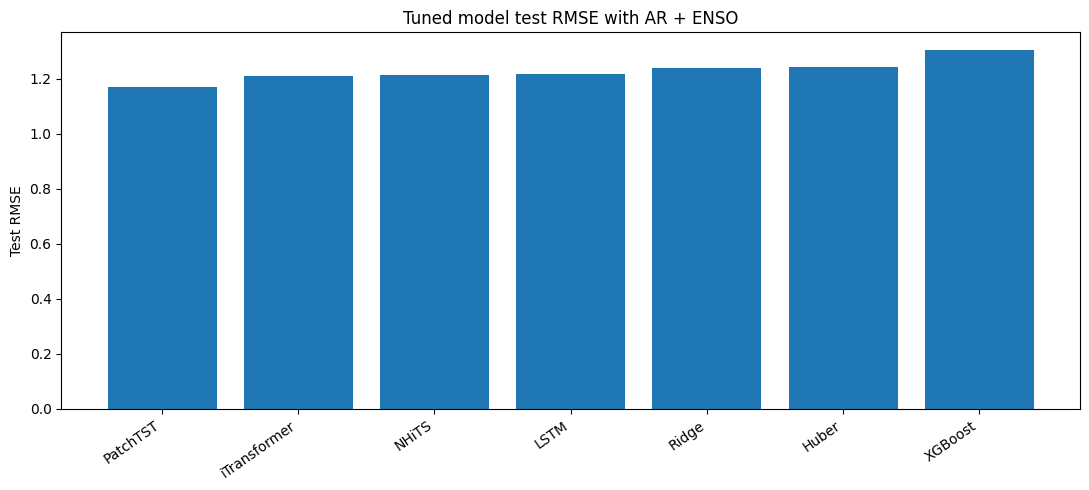

In [12]:
plot_df = benchmark_df.loc[~benchmark_df["strategy"].isin(["best_tuned_model"])]
plot_df = plot_df.sort_values("test_rmse").reset_index(drop=True)

plt.figure(figsize=(11, 5))
plt.bar(plot_df["strategy"], plot_df["test_rmse"])
plt.ylabel("Test RMSE")
plt.title("Tuned model test RMSE with AR + ENSO")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
save_current_plot("05_model_hypertuning_test_rmse_by_model.png")
plt.show()

### **Save outputs**

In [14]:
out_dir = PROJECT_ROOT / "notebooks_outputs"
out_dir.mkdir(parents=True, exist_ok=True)

best_val = overall_val_df.iloc[0]
best_test = overall_test_df.iloc[0]
summary_df = pd.DataFrame([{
    "feature_setup": "AR_plus_enso",
    "ar_lags": str(SELECTED_AR_LAGS),
    "enso_option": ENSO_LAG_OPTION,
    "enso_lags": str(ENSO_LAGS),
    "recency_half_life_months": BASE_CFG["half_life_months"],
    "month_group_size": BASE_CFG["month_group_size"],
    "use_month_alpha_choice": BASE_CFG["use_month_alpha_choice"],
    "best_val_model": str(best_val["Model"]),
    "val_rmse": float(best_val["RMSE"]),
    "val_mae": float(best_val["MAE"]),
    "val_bias": float(best_val["Bias"]),
    "best_test_model": str(best_test["Model"]),
    "test_rmse": float(best_test["RMSE"]),
    "test_mae": float(best_test["MAE"]),
    "test_bias": float(best_test["Bias"]),
    "n_tuned_models": len(overall_test_df),
}])

tuning_path = out_dir / "05_h1_enso_model_hypertuning_trials.csv"
selected_path = out_dir / "05_h1_enso_model_hypertuning_selected_model_settings.csv"
overall_test_path = out_dir / "05_h1_enso_model_hypertuning_overall_test_results.csv"
benchmark_path = out_dir / "05_h1_enso_model_hypertuning_benchmarks.csv"
summary_path = out_dir / "05_h1_enso_model_hypertuning_summary.csv"

tuning_results_df.to_csv(tuning_path, index=False)
selected_settings_df.to_csv(selected_path, index=False)
overall_test_df.to_csv(overall_test_path, index=False)
benchmark_df.to_csv(benchmark_path, index=False)
summary_df.to_csv(summary_path, index=False)

print("Saved:", project_relative(tuning_path))
print("Saved:", project_relative(selected_path))
print("Saved:", project_relative(overall_test_path))
print("Saved:", project_relative(benchmark_path))
print("Saved:", project_relative(summary_path))
summary_df

Saved: notebooks_outputs/05_h1_enso_model_hypertuning_trials.csv
Saved: notebooks_outputs/05_h1_enso_model_hypertuning_selected_model_settings.csv
Saved: notebooks_outputs/05_h1_enso_model_hypertuning_overall_test_results.csv
Saved: notebooks_outputs/05_h1_enso_model_hypertuning_benchmarks.csv
Saved: notebooks_outputs/05_h1_enso_model_hypertuning_summary.csv


,feature_setup,ar_lags,enso_option,enso_lags,recency_half_life_months,month_group_size,use_month_alpha_choice,best_val_model,val_rmse,val_mae,val_bias,best_test_model,test_rmse,test_mae,test_bias,n_tuned_models
0,AR_plus_enso,"(1, 2, 3, 6, 12, 18, 24)",enso_0,"(0,)",48,12,False,NHiTS,1.041291,0.814325,-0.223081,PatchTST,1.170461,0.922644,-0.268449,7


---

# **Part 4: Conclusion**

### **Overall Takeaways:**

- Notebook 05 tunes each retained model after the feature scope, training strategy, AR lag structure, and ENSO lag choice have already been fixed. The final setup uses AR + current ENSO only, sparse AR lags (1, 2, 3, 6, 12, 18, 24), 48-month recency weighting, and global model selection.
- Within the validation-selected hyperparameter sweep, NHiTS has the lowest validation RMSE near 1.041, using the wide setting. This makes it the strongest validation-only candidate.
- The held-out test comparison favors PatchTST, using the deeper setting. PatchTST has the lowest test RMSE near 1.170 and the lowest test MAE near 0.923, ahead of iTransformer, NHiTS, LSTM, and the linear/tree baselines.
- The NHiTS validation-to-test gap suggests that its validation advantage does not generalize as cleanly as PatchTST. PatchTST is also consistent with earlier global-selection results.
---